In [1]:
import otter
grader = otter.Notebook()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# DSCI 311 Fall 25 Midterm
## Due Date: Thursday 10/30 by 11:59 PM PST

**Collaboration Policy: No collaboration is allowed on this test. All work must be your own.**

**AI Policy**: You may use AI (and other internet resources) to *help* you answer questions. You may not copy any code wholesale from AI output. Consider AI as an informative assistant, *not* as a replacement for you (on this exam and in life). If I suspect purely AI-generated code, I'll ask you about it and expect you to explain clearly why you coded things in that way.

- An appropriate AI query: "I need to make this dataset longer but can't figure out the argument for turning columns into values. Can you help me understand the function?"

- An invalid AI query: "Give me code to make these data longer."

**Note that for ALL plotting questions, we will expect appropriate titles, axis labels, legends, etc. The following question serves as a good guideline on what is "enough": If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question?** 

This midterm may cover any topics through the first 4 weeks of class. You may be expected to do things that we have not explicitly shown in class or in an assignment - this is intentional, and why we expect you to reference function documentation (*e.g.* `help(pd.read_csv)`) or internet resources for help. But most of what you will do will have been shown either in lecture (in slides or in lecture notebooks) or in assignments. 

There are three sections to the midterm:

**Section 1**: Candy 

**Section 2**: Horror movies

**Section 3**: Hauntings

**Grader Tests**: As in homeworks, these tests only check whether your answer *could* be correct, not whether it is correct. 

## Section 1

Here we'll be reading in two datasets describing halloween candy - `candy_qualities.csv`, which contains traits associated with various halloween candies, and `candy_rankings.csv` which contains ranked preferences for each candy and a few additional characteristics as surveyed in 2017 with 269,000 votes. Our objective is simple: **determine the ultimate halloween candies and their characteristics**. The first step in this process will be to combine our data.

`candy_qualities.csv`:
    
    `name` - the name of the candy
    `quality` - some quality that may or may not represent the candy
    `value` - whether or not candy has the associated quality 

    Note that the quality 'pluribus' means candy that comes in multiples (think Skittles)
    
`candy_rankings.csv`: 

    `competitorname` - the name of the candy
    `sugarpercent` - the percentile of sugar it falls under in the data set
    `pricepercent` - the unit price percentile compared to the rest of the data set
    `winpercent` - the overall win percentage based on 269,000 matchups. 

Read in `candy_qualities.csv` and `candy_rankings.csv`.

In [3]:
candy_quals = pd.read_csv('data/candy_qualities.csv')

In [4]:
candy_quals.head()

,name,quality,value
0,100 Grand,chocolate,1
1,3 Musketeers,chocolate,1
2,One dime,chocolate,0
3,One quarter,chocolate,0
4,Air Heads,chocolate,0


In [5]:
candy_rankings = pd.read_csv('data/candy_rankings.csv')

In [6]:
candy_rankings.head()

,competitorname,sugarpercent,pricepercent,winpercent
0,100 Grand,0.732,0.860,66.971725
1,3 Musketeers,0.604,0.511,67.602936
2,One dime,0.011,0.116,32.261086
3,One quarter,0.011,0.511,46.116505
4,Air Heads,0.906,0.511,52.341465


#### Question 1

Our goal is to merge our two datasets together without duplicating any records. We therefore need to first format our datasets similarily. Pivot `candy_quals` so that there is only a **single record** (row) per candy. In other words, the granularity of the data should be at the level of candy name.

In [7]:
# DataFrame.pivot(*, columns, index=<no_default>, values=<no_default>)
# help(pd.pivot)

candy_wide = candy_quals.pivot(index = 'name', columns = 'quality', values = 'value').reset_index()
candy_wide

quality,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus
0,100 Grand,1,1,1,1,0,0,0,0,0
1,3 Musketeers,1,0,1,0,0,0,1,0,0
2,Air Heads,0,0,0,0,1,0,0,0,0
3,Almond Joy,1,0,1,0,0,0,0,1,0
4,Baby Ruth,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,0,0,0,1,0,0,0,0
81,Warheads,0,0,0,0,1,1,0,0,0
82,WelchÕs Fruit Snacks,0,0,0,0,1,0,0,0,1
83,WertherÕs Original Caramel,0,1,0,0,0,1,0,0,0


In [8]:
grader.check("q1_1")

q1_1 results: All test cases passed!

#### Question 2

To combine our two datasets, we need to canonicalize their keys. Identify all of the candy names in `candy_wide` that aren't matches in `candy_rankings`, returned as a Series or a numpy array.

In [9]:
# listt = []
# for i in candy_wide['name']:
#     if i not in candy_rankings['competitorname']:
#         listt.append(i)
#  for some reason, wasn't working and couldn't figure out with this for loop 


#  mismatches = candy_wide[candy_wide['name'].isin(candy_rankings['competitorname'])] 
# the one above finds all of the matches, and returns the matches, checking to see if the names in candy wide 
# are IN rankings, but we want the opposite, the ones that AREN'T in

# use the ~ , which basically flips everything for us. Turns the trues into falses and the falses into trues.
# (negation) 

mismatches = candy_wide[~candy_wide['name'].isin(candy_rankings['competitorname'])]['name']

# type(mismatches)
mismatches

20               HersheyÕs Kisses
21              HersheyÕs Krackel
22       HersheyÕs Milk Chocolate
23         HersheyÕs Special Dark
30                          M&MÕs
48            Peanut butter M&MÕs
52             ReeseÕs Miniatures
53      ReeseÕs Peanut Butter cup
54                 ReeseÕs pieces
55    ReeseÕs stuffed with pieces
82           WelchÕs Fruit Snacks
83     WertherÕs Original Caramel
Name: name, dtype: object

In [10]:
grader.check("q1_2")

q1_2 results: All test cases passed!

#### Question 3

Fix the issues in the key of `candy_wide` so that we can successfully merge our data (*i.e.* make these non-matching values match their counterparts in `candy_rankings`). 

In [11]:
# candy_wide['name'] this would work, but if we conver to string, it captures the "Õ" 
# candy_wide['name'].str

# DataFrame.replace(to_replace=None, value=<no_default>, *, inplace=False, limit=None, regex=False, method=<no_default>)[source]

In [12]:
candy_wide["name"] = candy_wide['name'].str.replace("Õ", "")
candy_wide

quality,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus
0,100 Grand,1,1,1,1,0,0,0,0,0
1,3 Musketeers,1,0,1,0,0,0,1,0,0
2,Air Heads,0,0,0,0,1,0,0,0,0
3,Almond Joy,1,0,1,0,0,0,0,1,0
4,Baby Ruth,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,0,0,0,1,0,0,0,0
81,Warheads,0,0,0,0,1,1,0,0,0
82,Welchs Fruit Snacks,0,0,0,0,1,0,0,0,1
83,Werthers Original Caramel,0,1,0,0,0,1,0,0,0


In [13]:
grader.check("q1_3")

q1_3 results: All test cases passed!

#### Question 4

Finally, merge the two Dataframes such that no information is lost in either frame. 

In [14]:
candy = candy_wide.merge(candy_rankings, left_on = 'name', right_on = 'competitorname', how = 'outer')
candy

,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus,competitorname,sugarpercent,pricepercent,winpercent
0,100 Grand,1,1,1,1,0,0,0,0,0,100 Grand,0.732,0.860,66.971725
1,3 Musketeers,1,0,1,0,0,0,1,0,0,3 Musketeers,0.604,0.511,67.602936
2,Air Heads,0,0,0,0,1,0,0,0,0,Air Heads,0.906,0.511,52.341465
3,Almond Joy,1,0,1,0,0,0,0,1,0,Almond Joy,0.465,0.767,50.347546
4,Baby Ruth,1,1,1,0,0,0,1,1,0,Baby Ruth,0.604,0.767,56.914547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,0,0,0,1,0,0,0,0,Twizzlers,0.220,0.116,45.466282
81,Warheads,0,0,0,0,1,1,0,0,0,Warheads,0.093,0.116,39.011898
82,Welchs Fruit Snacks,0,0,0,0,1,0,0,0,1,Welchs Fruit Snacks,0.313,0.313,44.375519
83,Werthers Original Caramel,0,1,0,0,0,1,0,0,0,Werthers Original Caramel,0.186,0.267,41.904308


In [15]:
grader.check("q1_4")

q1_4 results: All test cases passed!

#### Question 5

Plot the associations with regression lines between sugar % and win %, and price % and win %. Plot both associations on the same figure and ensure that each has a different color. Include a legend labeling each color. 

You can use any method you want for the regression lines, either estimating them manually or using seaborn's plotting functions. 

In [16]:
# seaborn.regplot(data=None, *, x=None, y=None, x_estimator=None, x_bins=None,
#                 x_ci='ci', scatter=True, fit_reg=True, ci=95, n_boot=1000, 
#                 units=None, seed=None, order=1, logistic=False, lowess=False, 
#                 robust=False, logx=False, x_partial=None, y_partial=None, 
#                 truncate=True, dropna=True, x_jitter=None, y_jitter=None, 
#                 label=None, color=None, marker='o', scatter_kws=None, 
#                 line_kws=None, ax=None)

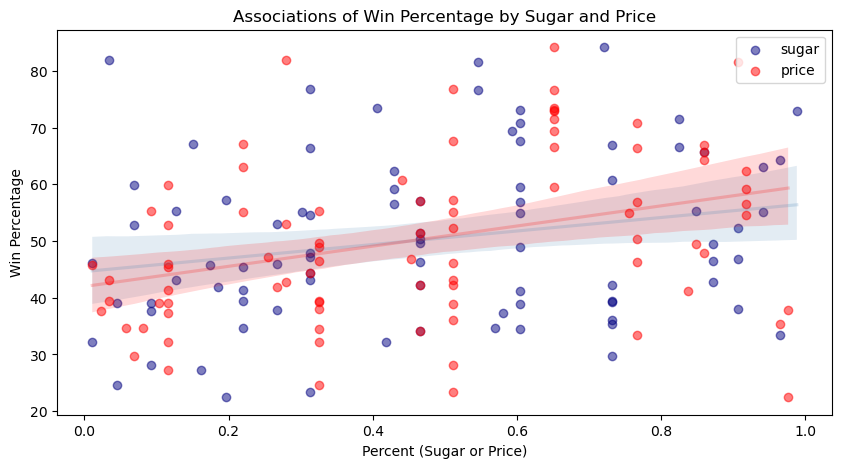

In [17]:
plt.figure(figsize = (10,5))

sns.regplot(data = candy, x = 'sugarpercent', y = 'winpercent', line_kws = dict(color = 'steelblue', alpha = 0.2), 
            scatter_kws = dict(color = 'navy', alpha = 0.5), label = 'sugar')

sns.regplot(data = candy, x = 'pricepercent', y = 'winpercent', line_kws = dict(color = 'red', alpha = 0.2),
           scatter_kws = dict(color = 'red', alpha = 0.5), label = 'price')


plt.xlabel('Percent (Sugar or Price)') 
plt.ylabel('Win Percentage')
plt.title('Associations of Win Percentage by Sugar and Price')
plt.legend()

## Question 6

What can we infer about more popular candy from the above plot?

**Your response**: It looks like the candy that has a higher win percentage tends to have slighlty higher sugar percentages and prices. Sugar percentage and Price percentage both show a slightly positive association with the win percentage. The win to price percentage seems to be a bit stronger. 

#### Question 7

Create a **horizontal** barplot representing the sums of each candy quality. Ensure the barplot is sorted from most to least.  

In [18]:
# DataFrame.plot.barh(x=None, y=None, **kwargs)

Text(0.5, 1.0, 'Sum of each quality of candy')

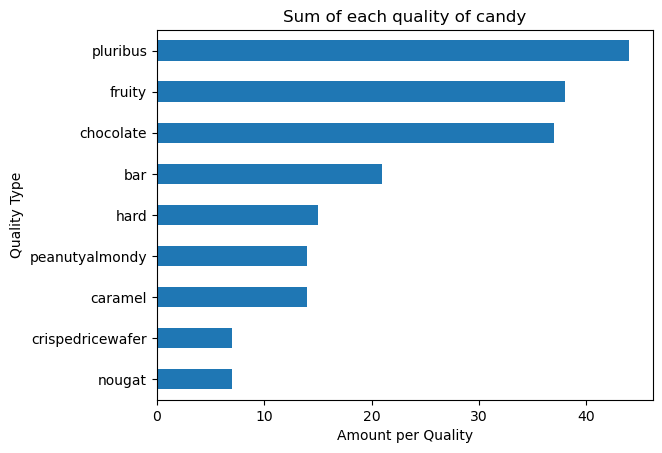

In [19]:

sums = candy[['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 'nougat',
       'crispedricewafer', 'hard', 'bar', 'pluribus']].sum().sort_values(ascending = True)

sums.plot.barh()
plt.xlabel('Amount per Quality')
plt.ylabel('Quality Type')
plt.title('Sum of each quality of candy')

#### Question 8

Now split the data into two subsets: the 50% of candy above the median of win percent and the 50% of candy below the median. Then plot a **paired**, horizontal barplot representing the same counts of each quality as above, where black bars represent the less popular candy and orange bars represent the more popular candy. 

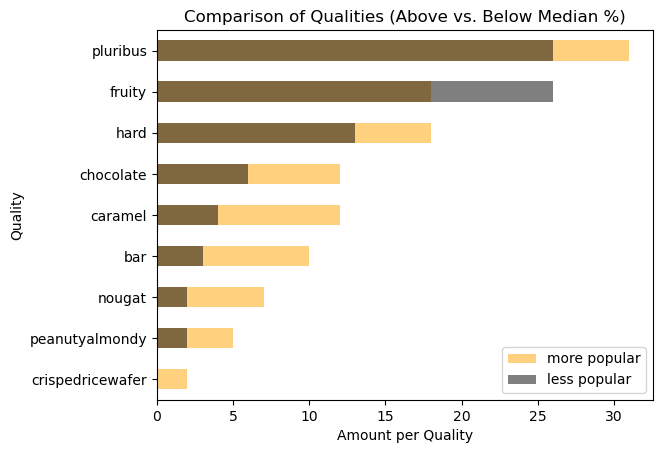

In [20]:
median = candy['winpercent'].median()

above = candy[candy['winpercent'] > median]
above1 = above[['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 'nougat',
       'crispedricewafer', 'hard', 'bar', 'pluribus']].sum().sort_values(ascending = True)

below = candy[candy['winpercent'] <= median]
below1 = below[['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 'nougat',
       'crispedricewafer', 'hard', 'bar', 'pluribus']].sum().sort_values(ascending = True)


above1.plot.barh(color = 'orange', alpha = 0.5, label = 'more popular')

below1.plot.barh(color = 'black', alpha = 0.5, label = 'less popular')

plt.xlabel('Amount per Quality')
plt.ylabel('Quality')
plt.title('Comparison of Qualities (Above vs. Below Median %)')
plt.legend()

#### Question 9

Characterize the most popular and the least popular halloween candy, giving extra emphasis to how they differ.

**Your response**: After plotting the bar graph, it seems that halloween candies tend to be more rich and sweeter, like chocolate, caramel, nougat, etc. The last popular candies seem to be more sugary taste, like fruity. Chocolate also tends to be more expensive, and overall better in taste, which is why we see this trend for halloween. 

## Section 2

Read in the `IMDB Horror Movies` dataset. This dataset represents a subset of some of the best-know movies in the horror genre released between 1920 and 2023.  

In [21]:
horror = pd.read_csv('data/Horror Movies imdb.csv')
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M
4,Tumbbad,2018,104,"Drama, Fantasy, Horror",8.2,Rahi Anil Barve,"53,297",NaN


#### Question 1

`Gross` represents the total amount each movie grossed in theatres in millions.

What type of variable does `Gross` represent? Based on your answer, what issues are there in the current formatting of the variable? 

In [22]:
type(horror['Gross'].loc[0])

str

**Your response**: Gross is the total amount of earning for each movie, calculated in millions. It is also in a string format, and the issue with that is that it is showing us a numeric value, but with a '.' and 'M' included. We can also see just by looking at the head() that we have NaN values. We should have Gross be in a float format, to keep the '.' .

#### Question 2

Clean a variable `Gross_clean` such that it is now the type of variable you identified above and can be used for analyses. We don't want to look at movies that didn't make any money, so also filter the data for values of `Gross_clean` greater than 0. 

In [110]:
horror['Gross_clean'] = (horror['Gross'].str.replace('$', '').str.replace('M', '')).astype(float)

# horror['Gross_clean'] = horror['Gross_clean'].dropna()
horror = horror[horror['Gross_clean'] > 0]

horror

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre,Genre_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90,Horror,Sci-Fi,None,Sci-Fi
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00,Horror,Mystery,Thriller,Mystery
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02,Drama,Horror,None,Drama
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78,Horror,Mystery,Sci-Fi,Mystery
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91,Horror,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,Slender Man I,2018,93,"Horror, Mystery, Thriller",3.2,Sylvain White,"36,238",$30.57M,30.57,Horror,Mystery,Thriller,Mystery
829,Jaws: The Revenge,1987,89,"Adventure, Horror, Thriller",3.0,Joseph Sargent,"47,708",$20.76M,20.76,Adventure,Horror,Thriller,Adventure
830,BloodRayne,2005,95,"Action, Fantasy, Horror",3.0,Uwe Boll,"36,527",$2.41M,2.41,Action,Fantasy,Horror,Action
833,Alone in the Dark,2005,96,"Action, Horror, Sci-Fi",2.4,Uwe Boll,"46,403",$5.18M,5.18,Action,Horror,Sci-Fi,Action


In [111]:
grader.check("q2_2")

q2_2 results: All test cases passed!

#### Question 3

First create a subset of the data filtering out NA values in `Gross_clean`. 

Then visualize the distributions of `Gross_clean` and `Rating`. Apply any tansformations to the data (if necessary) to make both variables approximately normally distributed. It's fine if there is still some tail to the distribution.

In [112]:
horror['Gross_clean'].isna().unique() # the code before had already dropped the NaN values 

horror['Gross_clean'].isna().unique(), horror['Gross_clean'].notna().unique()

horrorsub = horror.dropna(subset = ['Gross_clean'])
horrorsub

#horror['Gross_clean'] == horrorsub['Gross_clean']
#looks like the NA's are already gone, just checking above to make sure , we will use horrorsub to continue with the subset

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre,Genre_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90,Horror,Sci-Fi,None,Sci-Fi
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00,Horror,Mystery,Thriller,Mystery
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02,Drama,Horror,None,Drama
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78,Horror,Mystery,Sci-Fi,Mystery
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91,Horror,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,Slender Man I,2018,93,"Horror, Mystery, Thriller",3.2,Sylvain White,"36,238",$30.57M,30.57,Horror,Mystery,Thriller,Mystery
829,Jaws: The Revenge,1987,89,"Adventure, Horror, Thriller",3.0,Joseph Sargent,"47,708",$20.76M,20.76,Adventure,Horror,Thriller,Adventure
830,BloodRayne,2005,95,"Action, Fantasy, Horror",3.0,Uwe Boll,"36,527",$2.41M,2.41,Action,Fantasy,Horror,Action
833,Alone in the Dark,2005,96,"Action, Horror, Sci-Fi",2.4,Uwe Boll,"46,403",$5.18M,5.18,Action,Horror,Sci-Fi,Action


Text(0.5, 0, 'log Gross (in millions)')

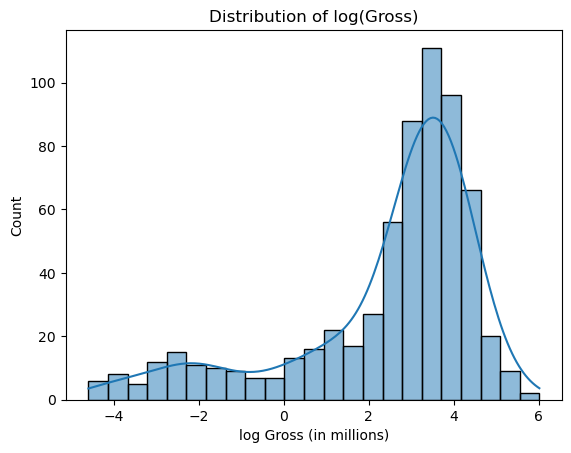

In [113]:
sns.histplot(x = np.log(horrorsub['Gross_clean']), kde = True)
plt.title('Distribution of log(Gross)')
plt.xlabel('log Gross (in millions)')

Text(0.5, 1.0, 'Distribution of ratings')

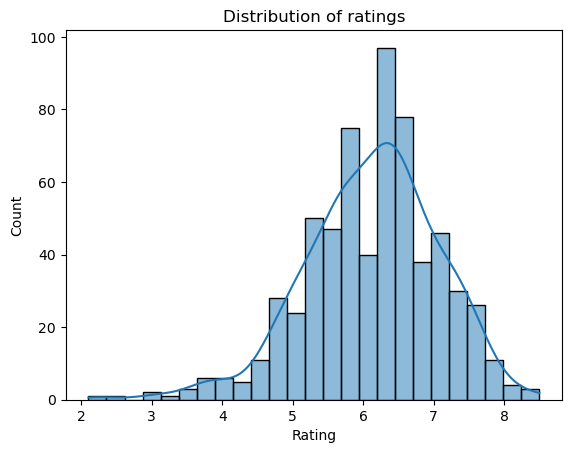

In [114]:
sns.histplot(x = horrorsub['Rating'], kde = True)
plt.title('Distribution of ratings')

Text(0.5, 1.0, 'Distributions of log(Gross) and ratings')

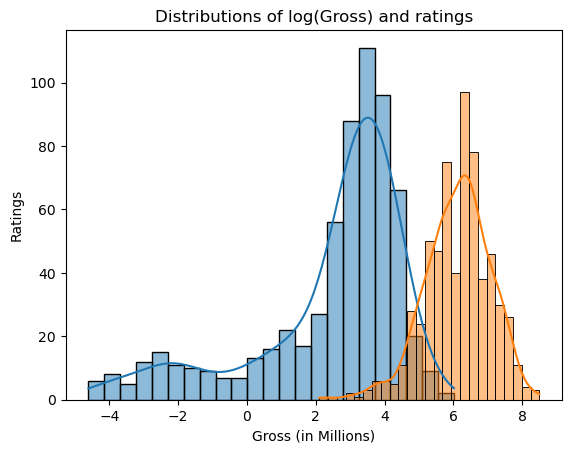

In [115]:
# sns.histplot(data = daily_counts, x = 'casual', color = 'blue', label = 'casual',
#              alpha = 0.2, kde = True, stat = 'density')

# sns.histplot(data = daily_counts, x = 'registered', color = 'green', label = 'registered', 
#              alpha = 0.4, kde = True, stat = 'density')
# this is from homework 4, working with histplots, using as reference 


# sns.histplot(x = np.log(horrorsub['Gross_clean']), y = np.log(horrorsub['Rating']))

sns.histplot(x = np.log(horrorsub['Gross_clean']), kde = True)
sns.histplot(x  = horrorsub['Rating'], kde = True)
plt.xlabel('Gross (in Millions)')
plt.ylabel('Ratings')
plt.title('Distributions of log(Gross) and ratings')


#### Question 4

One of the presumed characteristics of "oscar bait" i.e. films gunning for awards is a long runtime. Is there any evidence for this among horror movies? Evaluate this visually with a regression plot for each of the transformed and untransformed rating. 

Text(0.5, 1.0, 'Movie ratings vs. Runtime')

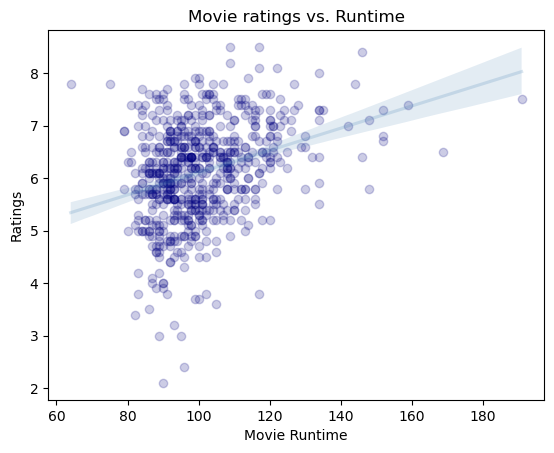

In [116]:
# "Oscar bait" is a term used to describe films that are perceived as being made 
# specifically to attract Academy Award nominations rather than for artistic merit

sns.regplot(data = horrorsub, x = 'Runtime', y = 'Rating',
            line_kws = dict(color = 'steelblue', alpha = 0.2), 
            scatter_kws = dict(color = 'navy', alpha = 0.2))

plt.xlabel('Movie Runtime')
plt.ylabel('Ratings')
plt.title('Movie ratings vs. Runtime')

Text(0.5, 1.0, 'Movie log(ratings) vs. Runtime')

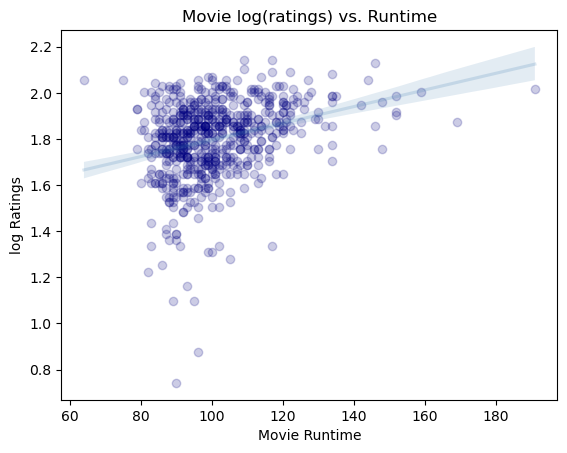

In [117]:
sns.regplot(x = horrorsub['Runtime'], y = np.log(horrorsub['Rating']),
            line_kws = dict(color = 'steelblue', alpha = 0.2), 
            scatter_kws = dict(color = 'navy', alpha = 0.2))

plt.xlabel('Movie Runtime')
plt.ylabel('log Ratings')
plt.title('Movie log(ratings) vs. Runtime')

#### Question 5

What do you conclude from the above visualization? Describe the association, and whether you think a simple linear model is an effective description of the relationship.

**Your response** After running the untransformed and transformed rating, they both share the same trend where there seems to be a slightly positive relationship between movie runtime and ratings, and we are able to see this more clearly when we look at the log(rating) regplot. The points come closer to the regression line, and it helps visually see the association easier. I would say that due to the variability, this graph wouldn't always be ideal, since variability can cause skewed results. 

#### Question 6

Who are the 5 most highly rated directors (on average) **among directors with at least 3 movies in the data**? Return your answer as a Series or numpy array.

In [118]:
over3 = horrorsub.groupby('Director')['Director'].value_counts().reset_index()
over3 = over3[over3['count'] >= 3]

best_directors = over3.merge(horrorsub, left_on = 'Director', right_on = 'Director', how = 'left')
best_directors = best_directors.groupby('Director')['Rating'].mean().sort_values(ascending = False)
best_directors = best_directors.head(5)
best_directors

Director
Jordan Peele        7.133333
David Cronenberg    7.116667
Sam Raimi           7.116667
Robert Rodriguez    7.100000
James Wan           6.966667
Name: Rating, dtype: float64

In [119]:
grader.check("q2_6")

q2_6 results: All test cases passed!

#### Question 8

Create three new columns in `horror` called `Primary Genre`, `Secondary Genre` and `Tertiary Genre`. These columns should be populated by the values in Genre in the order they appear. For example, the movie Alien should have "Horror" as its primary genre, "Sci-Fi" as its secondary genre, and "None" as its tertiary genre.

*Hint* You may want to review your string methods here.

In [120]:
horror['Primary Genre'] = horror['Genre'].str.split(',').str[0].fillna('None') 
# not sure if this would need fillna, just in case

horror['Secondary Genre'] = horror['Genre'].str.split(',').str[1].fillna('None')

horror['Tertiary Genre'] = horror['Genre'].str.split(',').str[2].fillna('None')

horror

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre,Genre_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90,Horror,Sci-Fi,None,Sci-Fi
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00,Horror,Mystery,Thriller,Mystery
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02,Drama,Horror,None,Drama
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78,Horror,Mystery,Sci-Fi,Mystery
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91,Horror,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,Slender Man I,2018,93,"Horror, Mystery, Thriller",3.2,Sylvain White,"36,238",$30.57M,30.57,Horror,Mystery,Thriller,Mystery
829,Jaws: The Revenge,1987,89,"Adventure, Horror, Thriller",3.0,Joseph Sargent,"47,708",$20.76M,20.76,Adventure,Horror,Thriller,Adventure
830,BloodRayne,2005,95,"Action, Fantasy, Horror",3.0,Uwe Boll,"36,527",$2.41M,2.41,Action,Fantasy,Horror,Action
833,Alone in the Dark,2005,96,"Action, Horror, Sci-Fi",2.4,Uwe Boll,"46,403",$5.18M,5.18,Action,Horror,Sci-Fi,Action


In [121]:
grader.check("q2_8")

q2_8 results: All test cases passed!

#### Question 9

All of the movies in the dataset are horror movies, so the inclusion of Horror as a genre isn't helpful. Create a new column called `Genre_clean` that represents either the primary genre of the movie, or the secondary genre if the primary genre of the movie is "Horror". There should therefore be no value of "Horror" in `Genre_clean`. 

For example, `Genre_clean` for Alien should be 'Sci-Fi', 'Mystery' for Psycho, and 'Drama' for The Shining.

In [122]:
horror['Genre_clean'] = horror['Genre'].str.replace('Horror,', '').str.replace('Horror', '').str.replace(', Horror', '')
# this code removes horror if it is in first, second, or third (includes the comma from both sides)

horror['Genre_clean'] = horror['Genre_clean'].str.split(',').str[0]
# split the values in genre clean, so we can choose the first one if there is two 
# str[0] chooses the first value if there is two 

horror

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre,Genre_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90,Horror,Sci-Fi,None,Sci-Fi
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00,Horror,Mystery,Thriller,Mystery
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02,Drama,Horror,None,Drama
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78,Horror,Mystery,Sci-Fi,Mystery
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91,Horror,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,Slender Man I,2018,93,"Horror, Mystery, Thriller",3.2,Sylvain White,"36,238",$30.57M,30.57,Horror,Mystery,Thriller,Mystery
829,Jaws: The Revenge,1987,89,"Adventure, Horror, Thriller",3.0,Joseph Sargent,"47,708",$20.76M,20.76,Adventure,Horror,Thriller,Adventure
830,BloodRayne,2005,95,"Action, Fantasy, Horror",3.0,Uwe Boll,"36,527",$2.41M,2.41,Action,Fantasy,Horror,Action
833,Alone in the Dark,2005,96,"Action, Horror, Sci-Fi",2.4,Uwe Boll,"46,403",$5.18M,5.18,Action,Horror,Sci-Fi,Action


In [123]:
grader.check("q2_9")

q2_9 results: All test cases passed!

#### Question 10

Have horror movies gotten better or worse through time? Visually evaluate this with a paired boxplot of ratings for the 3 most popular genres (genres with the highest incidence in the data) before and after the year 2000 (inclusive in either direction). 

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_17678/266287744.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top['Timeline'] = np.where(top['Movie Year'] < 2000, 'before 2000', 'after 2000')


Text(0.5, 1.0, "Movie ratings before and after the 2000's")

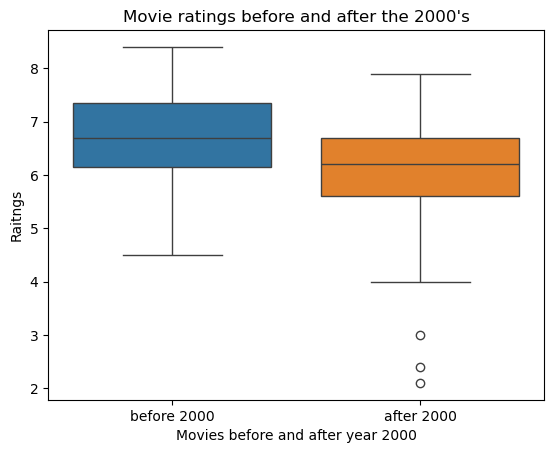

In [451]:
# mismatches = candy_wide[~candy_wide['name'].isin(candy_rankings['competitorname'])]['name']
# used isin earlier, 
# The result will only be true at a location if all the labels match. If values is a Series, that’s the index. 
# If values is a dict, the keys must be the column names, which must match. If values is a DataFrame, 
# then both the index and column labels must match. - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html

# sns.boxplot(data = pdx, x = 'recent', y = 'T', hue = 'recent')
# plt.title('Annual Temperatures of PDX before 1985 & after 1985')
# plt.xlabel('Time Period', fontsize = 11)
# plt.ylabel('Temperature (°C)', fontsize = 11)

# from homework # 3 , using as reference for box plot


most_popular = horror['Genre_clean'].value_counts()
# most_popular.head(3)
top3 = ['Action', 'Mystery', 'Drama']
# before2000 = horror[horror['Movie Year'] < 2000]
# after2000 = horror[horror['Movie Year'] > 2000]
# before2000 = before2000[before2000['Genre_clean'].isin(top3)]
top = horror[horror['Genre_clean'].isin(top3)]

top['Timeline'] = np.where(top['Movie Year'] < 2000, 'before 2000', 'after 2000')

sns.boxplot(data = top, x = 'Timeline', y = 'Rating', hue = 'Timeline')
plt.xlabel('Movies before and after year 2000')
plt.ylabel('Raitngs')
plt.title("Movie ratings before and after the 2000's")

## Section 3

Read in the `haunted_places` dataset. This is a dataset of all known haunting in the U.S. and associated descriptions. Each record is associated with one haunting. 

In [452]:
hauntings = pd.read_csv('data/haunted_places.csv')
hauntings.head()

,city,country,description,location,state,state_abbrev,longitude,latitude,city_longitude,city_latitude
0,Ada,United States,Ada witch - Sometimes you can see a misty blue...,Ada Cemetery,Michigan,MI,-85.504893,42.962106,-85.495480,42.960727
1,Addison,United States,A little girl was killed suddenly while waitin...,North Adams Rd.,Michigan,MI,-84.381843,41.971425,-84.347168,41.986434
2,Adrian,United States,If you take Gorman Rd. west towards Sand Creek...,Ghost Trestle,Michigan,MI,-84.035656,41.904538,-84.037166,41.897547
3,Adrian,United States,"In the 1970's, one room, room 211, in the old ...",Siena Heights University,Michigan,MI,-84.017565,41.905712,-84.037166,41.897547
4,Albion,United States,Kappa Delta Sorority - The Kappa Delta Sororit...,Albion College,Michigan,MI,-84.745177,42.244006,-84.753030,42.243097


#### Question 1

Read in the `state_populations` file and use it (with `haunted_places`) to determine which state has the most hauntings *per capita* in the United States (hauntings per individual). Return your answer as a string. 

In [453]:
pop = pd.read_csv('data/state_populations.csv')
# pop

#  state | population 

In [476]:
combine = pop.merge(hauntings, left_on = 'state', right_on = 'state', how = 'inner')
combine = combine.groupby('state')['location'].count().reset_index()
# this code above gets us the total number of hauntings per state

most_haunted = pop.merge(combine, on = 'state')

most_haunted['capita'] = most_haunted['location'] / most_haunted['population']

most_haunted = most_haunted.sort_values(by = 'capita', ascending = False).reset_index()

most_haunted = most_haunted['state'][0]
most_haunted

'Wyoming'

In [477]:
grader.check("q3_1")

q3_1 results: All test cases passed!

#### Question 2

The ratios of females to males in the U.S. is roughly 49/51 (or about 0.96). One would presume that hauntings reflect a similar sex ratio. 

What ratio of hauntings involve a girl versus a boy ($\frac{girl}{boy}$) and what ratio involve a woman versus a man ($\frac{woman}{man}$)?

In [478]:
boy = hauntings[hauntings['description'].str.contains('boy')]
girl = hauntings[hauntings['description'].str.contains('girl')]

girl_boy_ratio = girl['description'].count() / boy['description'].count()
girl_boy_ratio

1.8833967046894804

In [479]:
woman = hauntings[hauntings['description'].str.contains('woman')]
man = hauntings[hauntings['description'].str.contains('man')]

woman_man_ratio = woman['description'].count() / man['description'].count()
woman_man_ratio

0.26831460674157304

In [480]:
grader.check("q3_2")

q3_2 results: All test cases passed!

Is the ratio similar or different between the two subsets? What can we infer about how age affects the likelihood of different sexes lingering after death?

**Your response** The ratios between girl-boy to woman-man are very different than one another. For a girl to boy, a girl is almost twice is likely to experience a haunting compared to a boy. On the other hand, from woman to man, a woman is only around 29% as likely to experience a haunting compared to a man. We see that at younger ages, girls are more likely to experience a haunting, and then the roles flip as they get older. 

#### Question 3

Create a horizontal barplot of the 20 most common locations in the haunting descriptions. Be sure to lowercase all of the words. The resulting barchart should *only* include general location names (e.g. hospital, cemetary, house), not proper nouns (e.g. the specific name of a hospital), articles (e.g "the", "an", "is" etc...) or adjectives. Multiple words for the same thing is ok (e.g. street and road).

In [548]:
# horror['Genre_clean'] = horror['Genre'].str.replace('Horror,', '').str.replace('Horror', '').str.replace(', Horror', '')
# this code removes horror if it is in first, second, or third (includes the comma from both sides)

# bike['weekday'] = bike['weekday'].replace([0, 1, 2, 3, 4, 5, 6], ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'])
# this code is from my homework 4, where i use replace and use a list to replace

# hauntings['description'] = hauntings[hauntings['description'].str.lower()]

hauntings['description'] = hauntings['description'].str.lower()

# pattern = r'\[(\d+)/(\w+)/(\d+):(\d+):(\d+):(\d+) (.+)\]'
# text_and_cleaning_07 ipynb from class

# common = hauntings

# common['area'] = common['description'].str.replace(
#     r'\b(the|an|is|you|a|was|one|in|can|see|with|one|two|three|sometimes|room|old|room|of|haunted||by|he|she)\b', '', regex = True)

# common['area'].value_counts()

# probably overthinking it, starting over 

hauntings['clean'] = hauntings['description'].str.replace(
    r'\b(sometimes|you|can|of|to|that|been|be|a|little|girl|was|while|one|in|the|at|with|for|their|kids|from|boy|it|their|her|his|is|one|two|year|years|by|have|and|there|as|on|an)\b', '', 
    regex = True)

# Series.str.split(pat=None, *, n=-1, expand=False, regex=None)
# Expand the split strings into separate columns.
# If True, return DataFrame/MultiIndex expanding dimensionality.
# If False, return Series/Index, containing lists of strings.

# DataFrame.stack(level=-1, dropna=<no_default>, sort=<no_default>, future_stack=False)[source]
# Return a reshaped DataFrame or Series having a multi-level index with one or more new inner-most 
# levels compared to the current DataFrame. The new inner-most levels are created by pivoting the 
# columns of the current dataframe:
    
words = hauntings['clean'].str.split(expand = True).stack().value_counts().reset_index()

scary = ['hospital', 'cemetery', 'cemetary', 'house', 'road', 'school', 'bridge', 'university', 'room', 'office', 'aisle',
        'hotel', 'asylum', 'prison', 'castle', 'catacomb', 'ship', 'boat', 'island', 'town', 'hallway', 'hall',
        'store', 'building', 'street']

places = words[words['index'].isin(scary)]
places = places.head(20).sort_values(by = 'count')

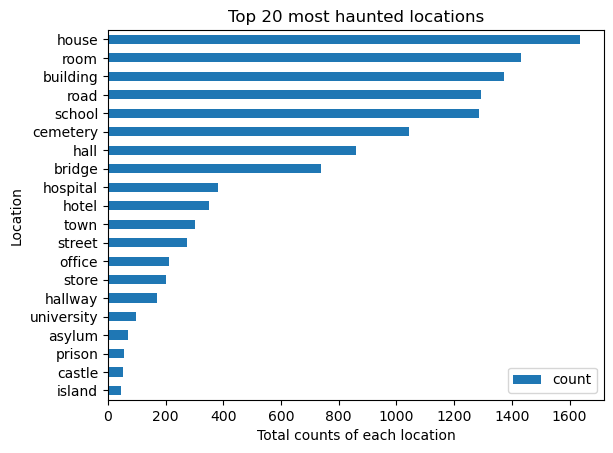

In [549]:
places.plot.barh(x = 'index', y = 'count')
plt.xlabel('Total counts of each location')
plt.ylabel('Location')
plt.title('Top 20 most haunted locations')
plt.legend()

Why do you suppose some of these places are more haunted than others?

**Your response**: It seems like most places that are haunted tend to be in areas where there is higher traffic. For example, house and room being the top two are very closely related as there is a bunch of rooms in a house, and that's where people always are. As you go down the graph, the areas become slightly more isolated and not as much people there. 
Another thing to notice is besides the traffic, the top places are places where there is usually someone either always there, or a place that people go back to very often.

#### Question 4

In your opinion, what is the scariest haunting in Eugene?

**Your response**: Probably the Pioneer Cemetery 

# Submission

**That's a wrap!** I hope this exam didn't jump scare you.

Be sure to check that all of your tests pass the autograder.

In [550]:
grader.check_all()

q1_1 results: All test cases passed!

q1_2 results: All test cases passed!

q1_3 results: All test cases passed!

q1_4 results: All test cases passed!

q2_2 results: All test cases passed!

q2_6 results: All test cases passed!

q2_8 results: All test cases passed!

q2_9 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

Make sure you have run all cells in your notebook in order. Then execute the following in the File menu

* Save and Checkpoint
* Close and Halt

Then upload your notebook to Canvas Assignment Midterm.